# Hardware Pulse: Model Evaluation

This notebook evaluates and compares price forecasting models.

**Task**: Predict next week's price using this week's data (forecasting, not regression)
- **Target (y)**: `mediana_movil` — median price of the current week
- **Primary feature**: `precio_lag_1` — median price of the previous week
- **Additional features**: `dispersion_precios`, `usd_uyu_rate`

**Models compared:**
- **Baseline**: NaivePersistenceModel (predicts next week's price = this week's price)
- **ElasticNet**: Regularized linear model with lag and market features

**Target metric**: MAPE (Mean Absolute Percentage Error)

**Data limitation**: Only 3 weeks of data available, so `precio_lag_1` is only populated
for weeks 2-3. This gives us ~6 usable rows for evaluation. Results are noisy but
the exercise is conceptually correct.

## Setup

In [15]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
sys.path.insert(0, "..")

from src.models import (
    NaivePersistenceModel,
    ElasticNetPriceModel,
    evaluate_model_performance,
)

In [16]:
# --- Config ---
DB_PATH = Path("../data/hardware_pulse.db")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

## Section 1: Load Data

Read `feature_snapshots` from the database — the aggregated weekly features
per SKU that serve as input to the models.

In [17]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM feature_snapshots ORDER BY week_start", conn)
conn.close()

print(f"Loaded feature_snapshots: {len(df)} rows")
df.head()

Loaded feature_snapshots: 45 rows


,id,week_start,canonical_product_id,run_at,precio_lag_1,precio_lag_2,mediana_movil,dispersion_precios,usd_uyu_rate
0,293,2026-04-20,AMD Athlon 3000G,2026-05-07T20:30:03.253271+00:00,NaN,NaN,56.0,7.483315,39.913744
1,294,2026-04-20,Arc A580,2026-05-07T20:30:03.253271+00:00,NaN,NaN,294.5,8.156774,39.913744
2,295,2026-04-20,Arc B570,2026-05-07T20:30:03.253271+00:00,NaN,NaN,354.5,0.518875,39.913744
3,296,2026-04-20,Arc B580,2026-05-07T20:30:03.253271+00:00,NaN,NaN,440.0,5.188745,39.913744
4,297,2026-04-20,Intel Core i3 12100F,2026-05-07T20:30:03.253271+00:00,NaN,NaN,104.5,9.350325,39.913744


## Section 2: Quick Exploration

In [18]:
print("=== Dataset Overview ===")
print(f"Rows: {len(df)}")
print(f"Unique SKUs: {df['canonical_product_id'].nunique()}")
print(f"Weeks covered: {df['week_start'].nunique()}")
print(f"\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Overview ===
Rows: 45
Unique SKUs: 36
Weeks covered: 3

=== Missing Values ===
id                       0
week_start               0
canonical_product_id     0
run_at                   0
precio_lag_1            36
precio_lag_2            43
mediana_movil            0
dispersion_precios       3
usd_uyu_rate             0
dtype: int64


In [19]:
print("=== Rows per SKU ===")
display(df["canonical_product_id"].value_counts().describe())

print("\n=== Availability of Lag Features ===")
print(f"precio_lag_1 (previous week price): {df['precio_lag_1'].notna().sum()} non-null rows")
print(f"precio_lag_2 (2 weeks ago): {df['precio_lag_2'].notna().sum()} non-null rows")

=== Rows per SKU ===


count    36.000000
mean      1.250000
std       0.554205
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: count, dtype: float64


=== Availability of Lag Features ===
precio_lag_1 (previous week price): 9 non-null rows
precio_lag_2 (2 weeks ago): 2 non-null rows


## Section 3: Prepare Data for Forecasting

This is a proper forecasting task:
- **Target (y)**: `mediana_movil` — this week's median price
- **Primary feature**: `precio_lag_1` — previous week's median price (the lag)
- **Additional features**: `dispersion_precios`, `usd_uyu_rate`

We use `precio_lag_1` as the main feature, which represents the
"persistence" baseline: next week's price is predicted using this week's price.

Note: We drop rows where `precio_lag_1` is NaN — these are the first week
observations where we have no prior data to forecast from.

In [20]:
# Define features and target
TARGET_COL = "mediana_movil"
FEATURE_COLS = ["precio_lag_1", "dispersion_precios", "usd_uyu_rate"]

# Drop rows with missing precio_lag_1 (required for forecasting)
df_with_lag = df.dropna(subset=["precio_lag_1"]).copy()
print(f"Rows with precio_lag_1 available: {len(df_with_lag)}")

# Drop remaining NaNs in other features and target
df_clean = df_with_lag.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
df_clean = df_clean.sort_values(["canonical_product_id", "week_start"]).reset_index(drop=True)

print(f"\nRows after full cleaning: {len(df_clean)}")
print(f"Unique SKUs: {df_clean['canonical_product_id'].nunique()}")
print(f"Unique weeks: {df_clean['week_start'].nunique()}")
print(f"\n⚠️  WARNING: With only {len(df_clean)} rows, results will be noisy.")
print("This is the correct approach conceptually, but needs more data for reliable metrics.")

Rows with precio_lag_1 available: 9

Rows after full cleaning: 6
Unique SKUs: 6
Unique weeks: 2

⚠️  WARNING: With only 6 rows, results will be noisy.
This is the correct approach conceptually, but needs more data for reliable metrics.


## Section 4: Baseline — NaivePersistenceModel

The naive baseline predicts next week's price = this week's price.
This is the "persistence" or "random walk" forecast — the standard
baseline for time series forecasting.

In [21]:
# Evaluate NaivePersistenceModel
# The naive model uses precio_lag_1 as the feature (previous week's price = prediction)
naive_model = NaivePersistenceModel(price_column="precio_lag_1")
naive_result = evaluate_model_performance(
    model=naive_model,
    df=df_clean,
    target_col=TARGET_COL,
    feature_cols=FEATURE_COLS,
    split_ratio=0.7,  # Use 70% train since we have few rows
)

print("=== NaivePersistenceModel Results ===")
for metric, value in naive_result.metrics.items():
    print(f"{metric.upper()}: {value:.4f}")

=== NaivePersistenceModel Results ===
MAE: 35.2500
RMSE: 45.8053
MAPE: 8.3383


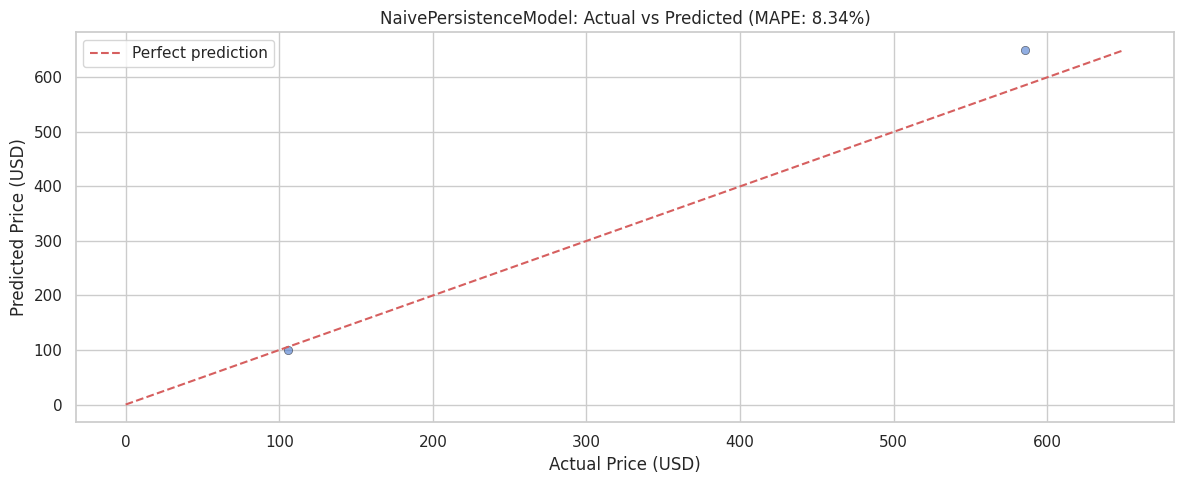

In [22]:
# Visualization: Actual vs Predicted (Naive)
fig, ax = plt.subplots()
ax.scatter(naive_result.actuals, naive_result.predictions, alpha=0.6, edgecolors="k", linewidth=0.5)
max_val = max(naive_result.actuals.max(), naive_result.predictions.max())
ax.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
ax.set_xlabel("Actual Price (USD)")
ax.set_ylabel("Predicted Price (USD)")
ax.set_title(f"NaivePersistenceModel: Actual vs Predicted (MAPE: {naive_result.metrics['mape']:.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()

## Section 5: ElasticNet Model

ElasticNet adds learned coefficients to the lag feature, potentially
improving over the naive baseline by adjusting predictions based on
price dispersion and exchange rate movements.

In [23]:
# Evaluate ElasticNetPriceModel
elasticnet_model = ElasticNetPriceModel(alpha=1.0, l1_ratio=0.5)
elasticnet_result = evaluate_model_performance(
    model=elasticnet_model,
    df=df_clean,
    target_col=TARGET_COL,
    feature_cols=FEATURE_COLS,
    split_ratio=0.7,
)

print("=== ElasticNetPriceModel Results ===")
for metric, value in elasticnet_result.metrics.items():
    print(f"{metric.upper()}: {value:.4f}")

=== ElasticNetPriceModel Results ===
MAE: 414.8719
RMSE: 418.2859
MAPE: 251.7258


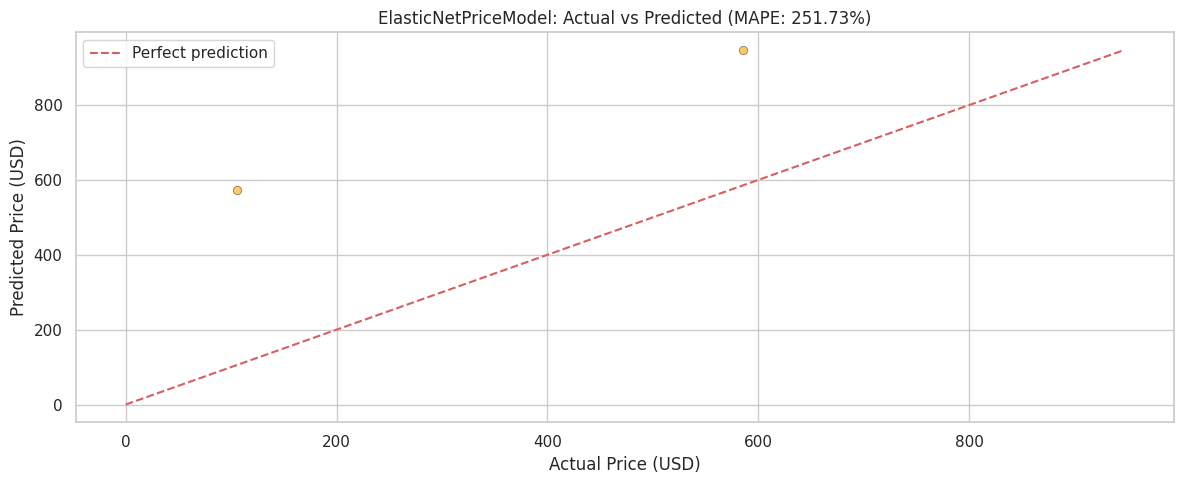

In [24]:
# Visualization: Actual vs Predicted (ElasticNet)
fig, ax = plt.subplots()
ax.scatter(elasticnet_result.actuals, elasticnet_result.predictions, alpha=0.6, edgecolors="k", linewidth=0.5, color="orange")
max_val = max(elasticnet_result.actuals.max(), elasticnet_result.predictions.max())
ax.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
ax.set_xlabel("Actual Price (USD)")
ax.set_ylabel("Predicted Price (USD)")
ax.set_title(f"ElasticNetPriceModel: Actual vs Predicted (MAPE: {elasticnet_result.metrics['mape']:.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()

## Section 6: Model Comparison

In [25]:
# Compare metrics side by side
comparison_df = pd.DataFrame({
    "NaivePersistenceModel": naive_result.metrics,
    "ElasticNetPriceModel": elasticnet_result.metrics,
}).T

print("=== Model Comparison ===")
display(comparison_df.round(4))

# Calculate improvement
mape_naive = naive_result.metrics["mape"]
mape_elasticnet = elasticnet_result.metrics["mape"]
improvement = ((mape_naive - mape_elasticnet) / mape_naive) * 100

print(f"\n{'='*40}")
if mape_elasticnet < mape_naive:
    print(f"✅ ElasticNet beats baseline by {improvement:.2f}% in MAPE")
else:
    print(f"❌ ElasticNet does NOT beat baseline (diff: {mape_elasticnet - mape_naive:.2f}%)")
print(f"{'='*40}")

=== Model Comparison ===


,mae,rmse,mape
NaivePersistenceModel,35.2500,45.8053,8.3383
ElasticNetPriceModel,414.8719,418.2859,251.7258



❌ ElasticNet does NOT beat baseline (diff: 243.39%)


In [26]:
# Per-SKU comparison (if we have enough test samples)
test_idx = elasticnet_result.predictions.index
if len(test_idx) > 0:
    df_test = df_clean.loc[test_idx].copy()
    df_test["naive_pred"] = naive_result.predictions.values
    df_test["elasticnet_pred"] = elasticnet_result.predictions.values
    df_test["actual"] = naive_result.actuals.values
    df_test["naive_mape"] = abs(df_test["actual"] - df_test["naive_pred"]) / df_test["actual"] * 100
    df_test["elasticnet_mape"] = abs(df_test["actual"] - df_test["elasticnet_pred"]) / df_test["actual"] * 100
    df_test["winner"] = df_test.apply(lambda r: "ElasticNet" if r["elasticnet_mape"] < r["naive_mape"] else "Naive", axis=1)

    print("=== Per-SKU Winner ===")
    display(df_test["winner"].value_counts())
    
    print("\n=== SKUs where ElasticNet wins ===")
    display(df_test[df_test["winner"] == "ElasticNet"]["canonical_product_id"].value_counts().head(10))
    
    print("\n=== SKUs where Naive wins ===")
    display(df_test[df_test["winner"] == "Naive"]["canonical_product_id"].value_counts().head(10))
else:
    print("⚠️  No test samples available for per-SKU analysis")

=== Per-SKU Winner ===


winner
Naive    2
Name: count, dtype: int64


=== SKUs where ElasticNet wins ===


Series([], Name: count, dtype: int64)


=== SKUs where Naive wins ===


canonical_product_id
RX 9060 XT      1
Ryzen 5 4500    1
Name: count, dtype: int64

## Section 7: Feature Importance (ElasticNet)

In [27]:
# Get feature importances from ElasticNet
importances = elasticnet_model.feature_importances()

print("=== ElasticNet Feature Coefficients ===")
display(importances.to_frame("coefficient").round(4))

=== ElasticNet Feature Coefficients ===


,coefficient
precio_lag_1,469.1642
dispersion_precios,-97.3381
usd_uyu_rate,-33.8241


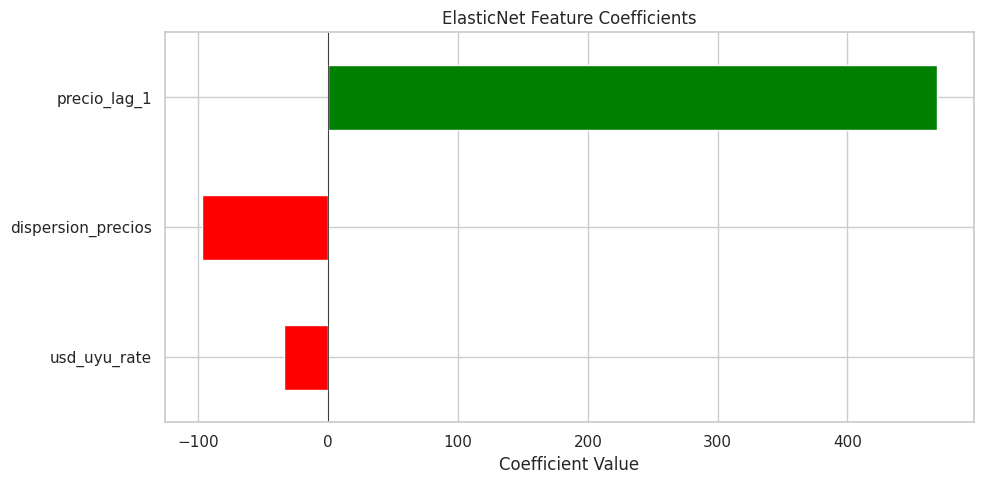

In [28]:
# Visualization: Feature importances
fig, ax = plt.subplots(figsize=(10, 5))
importances_sorted = importances.reindex(importances.abs().sort_values(ascending=True).index)
colors = ["green" if c > 0 else "red" for c in importances_sorted]
importances_sorted.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Coefficient Value")
ax.set_title("ElasticNet Feature Coefficients")
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

## Summary

### Data Limitation Note
This notebook uses proper forecasting methodology:
- Predict next week's price using this week's data (including the lag feature)
- No data leakage — training data precedes test data temporally

However, with only 3 weeks of data, we have just 6 usable rows for evaluation.
Results are noisy and should not be used for production decisions.

### Next Steps
- Collect more weekly data (ideally 12+ weeks for reliable evaluation)
- Re-run this notebook to get stable metrics
- Consider hyperparameter tuning once more data is available

Run the cells above to see the comparison table with actual metrics.